# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [3]:
df = pd.read_csv('CHURN_TELECON_MOD08_TAREFA_PART2.csv', delimiter=',')
df.head()

,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,TV_Por_Streaming,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,FEMALE,0,Yes,No,1,No,DSL,No,No,No,MONTH-TO-MONTH,ELECTRONIC CHECK,29.85,29.85,No
1,MALE,0,No,No,34,Yes,DSL,Yes,No,No,ONE YEAR,MAILED CHECK,56.95,1889.50,No
2,MALE,0,No,No,2,Yes,DSL,Yes,No,No,MONTH-TO-MONTH,MAILED CHECK,53.85,108.15,Yes
3,MALE,0,No,No,45,No,DSL,Yes,Yes,No,ONE YEAR,BANK TRANSFER (AUTOMATIC),71.45,1840.75,No
4,FEMALE,0,No,No,52,Yes,NO,No,No,No,ONE YEAR,MAILED CHECK,71.45,1022.95,No


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [4]:
df.describe()

,Idoso,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago
count,2488.000000,2488.000000,2488.000000,2488.000000
mean,0.161576,32.352090,66.342564,2290.087178
std,0.368135,24.636885,28.051718,2264.585643
min,0.000000,0.000000,18.400000,18.800000
25%,0.000000,8.000000,45.400000,402.337500
50%,0.000000,29.000000,71.450000,1402.900000
75%,0.000000,56.000000,87.712500,3867.162500
max,1.000000,72.000000,118.650000,8564.750000


Através da função describe conseguimos identificar possíveis outliers nas colunas 'Tempo como Cliente', pois o min está como 0, e nas colunas 'Pagamento Mensal' e 'Total Pago' a média está distante dos 50% dos dados, indicando valores que estão afentando diretamente a média.

In [6]:
(df['Tempo_como_Cliente'] == 0).sum()

np.int64(5)

In [7]:
(df['Tempo_como_Cliente'] == 0).mean() * 100

np.float64(0.20096463022508038)

In [6]:
df[df['Tempo_como_Cliente'] == 0]

,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,TV_Por_Streaming,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
476,FEMALE,0,Yes,Yes,0,Unknown,DSL,Yes,Yes,Yes,TWO YEAR,BANK TRANSFER (AUTOMATIC),52.55,52.55,No
741,MALE,0,No,Yes,0,Unknown,NO,No,No,No,TWO YEAR,MAILED CHECK,20.25,40.50,No
924,FEMALE,0,Yes,Yes,0,Unknown,DSL,Yes,No,Yes,TWO YEAR,MAILED CHECK,80.85,80.85,No
1070,MALE,0,Yes,Yes,0,Unknown,NO,No,No,No,TWO YEAR,MAILED CHECK,25.75,25.75,No
1328,FEMALE,0,Yes,Yes,0,Unknown,DSL,Yes,Yes,Yes,TWO YEAR,CREDIT CARD (AUTOMATIC),56.05,56.05,No


In [15]:
fig = px.box(df, y='Tempo_como_Cliente', title='BoxPlot de Tempo como Cliente')
fig.show()

Observamos que mesmo que a coluna 'Tempo como Cliente' tenha valores 0, eles representam uma porcentagem pequena (0.2%) dos dados, e o gráfico confirma que essa pequena porcentagam de dados 0 não afeta na visualização da distribuição do boxplot.  

Obs: Essa coluna 'Tempo como Cliente', conta de mes em mes, logo esses valores como 0, podem indicar que alguns clientes ainda não completaram um mes de serviço com a empresa. Com excessão de um cliente que tem ppagamento mensal (20.25), mas tem (40.50) como total pago, indicando uma possível falha no cadastro.

In [7]:
fig = px.box(df, y='Pagamento_Mensal', title='BoxPlot de Pagamento Mensal')
fig.show()

Observa-se no boxplot da coluna 'Pagamento Mensal' que apesar dos 50% dos dados e média estarem distantes, não há outliers que estejam aumentando ou diminuindo drasticamente os dados. Logo, a explicação para esse comportamento está nos diferentes tipos de planos, com valores diferentes, tendo de (18.4 até 118.65). Ou seja, apesar de terem dados com valores diferentes e distantes, não podemos modificá-los pois trata-se de planos com valores distintos.

In [8]:
fig = px.box(df, y='Total_Pago', title='BoxPlot de Total Pago')
fig.show()

Atravéz da análise do gráfico percebe-se uma diferença grande nos valores mínimos e máximos dos dados, e assim como no gráfico anterior não há de fato outliers. Essa coluna precisa de uma interpretação um pouco mais aprofundada pois ela tem relação direta com as colunas 'Tempo como Cliente' e 'Pagamento Mensal', sendo o resultado da multiplição dessas duas colunas. Ou seja, há clientes com diferentes tipos de planos e tempo de serviço, portanto a coluna 'Total Pago' terá valores muitos diferentes, que não podem ser tratados como outliers.

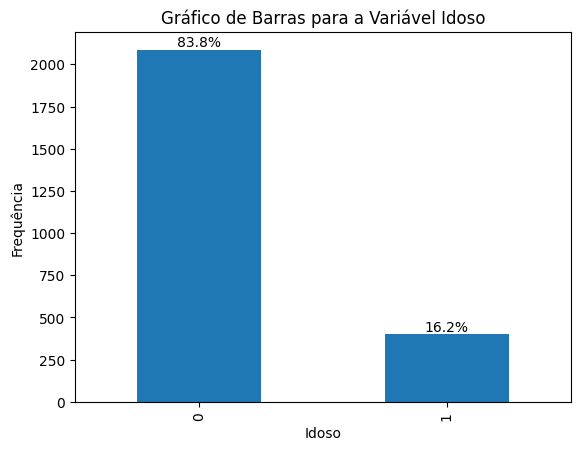

In [27]:
contagem = df['Idoso'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Idoso')
plt.xlabel('Idoso')
plt.ylabel('Frequência')

plt.show()

Nota-se que ara a variável 'Idoso', a grande maioria dos nossos clientes não são idosos (cerca de 83%). 

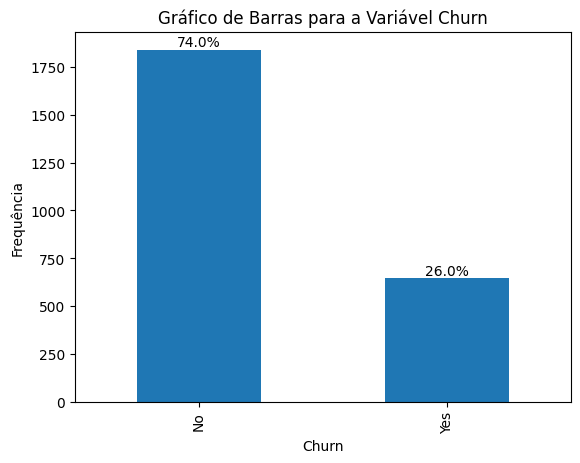

In [34]:
contagem = df['Churn'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Churn')
plt.xlabel('Churn')
plt.ylabel('Frequência')

plt.show()

Para a variável 'Churn', percebe-se que a maior parte dos clientes não dão churn (cerca de 74% da base de dados). 

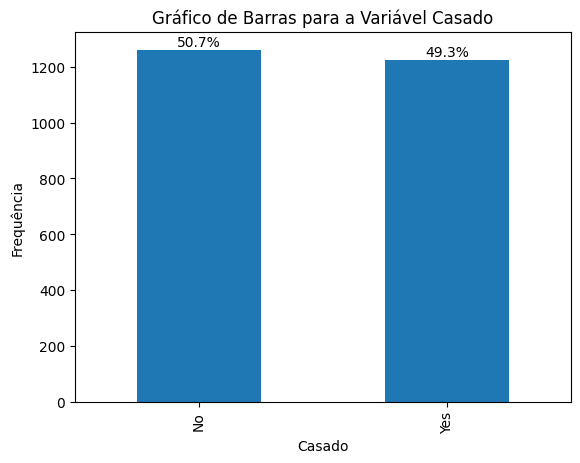

In [23]:
contagem = df['Casado'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Casado')
plt.xlabel('Casado')
plt.ylabel('Frequência')

plt.show()

Já para a variável 'Casado', nota-se um balanceamento entre as duas classes.

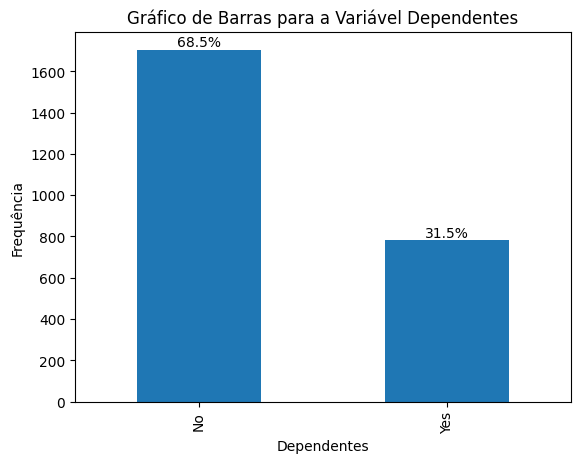

In [22]:
contagem = df['Dependentes'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Dependentes')
plt.xlabel('Dependentes')
plt.ylabel('Frequência')

plt.show()

Para a variável 'Dependentes', nota-se que a maior parte de clientes não possuem dependentes (cerca de 68%).

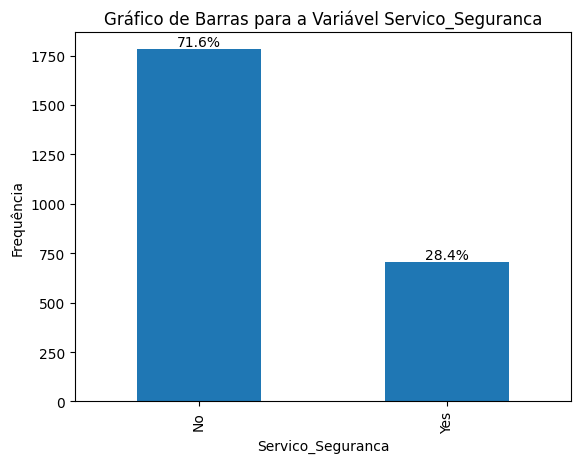

In [29]:
contagem = df['Servico_Seguranca'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Servico_Seguranca')
plt.xlabel('Servico_Seguranca')
plt.ylabel('Frequência')

plt.show()

Visualiza-se na variável 'Servico_Seguranca' que a maior parte de clientes não possum serviço de segurança (cerca de 71% da base de dados).

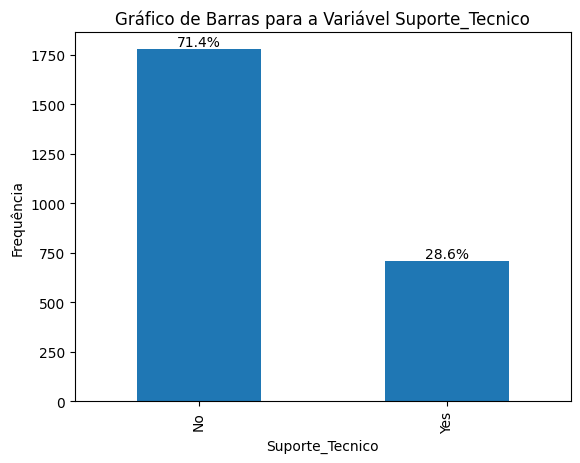

In [30]:
contagem = df['Suporte_Tecnico'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Suporte_Tecnico')
plt.xlabel('Suporte_Tecnico')
plt.ylabel('Frequência')

plt.show()

Para a variável 'Suporte_Tecnico', nota-se que a maior parte de clientes não possui este serviço (cerca de 71%).

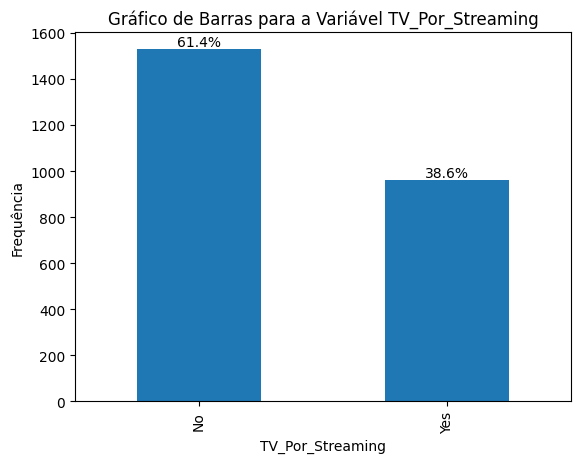

In [31]:
contagem = df['TV_Por_Streaming'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável TV_Por_Streaming')
plt.xlabel('TV_Por_Streaming')
plt.ylabel('Frequência')

plt.show()

Enquanto que na variável 'TV_Por_Streaming', a maior parte de clientes não possui este tipo de serviço (cerca de 61% da base de dados).

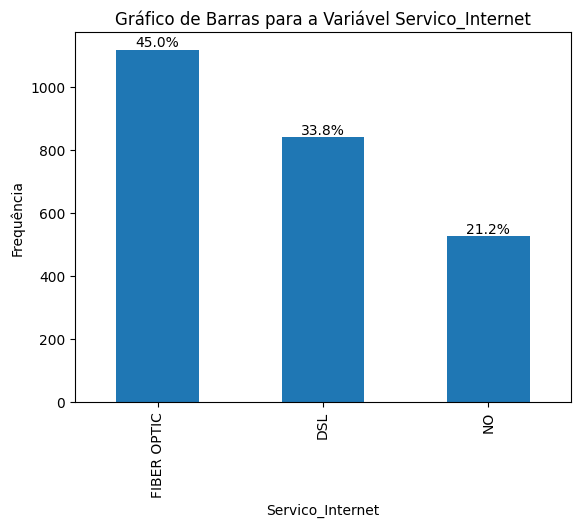

In [26]:
contagem = df['Servico_Internet'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Servico_Internet')
plt.xlabel('Servico_Internet')
plt.ylabel('Frequência')

plt.show()

Identifica-se que a maior parte de clientes possui o servico de internet 'FIBER OPTIC'.

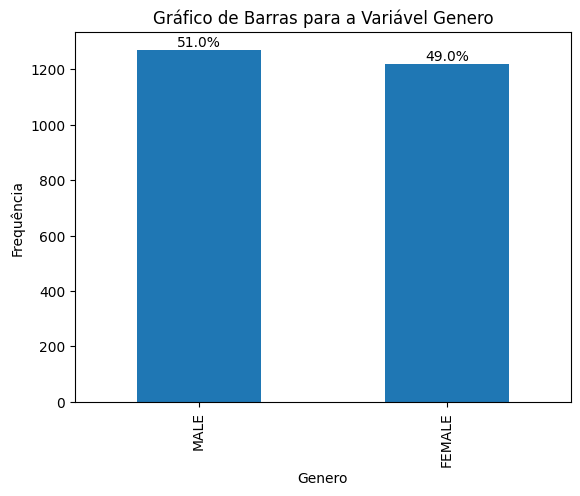

In [24]:
contagem = df['Genero'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Genero')
plt.xlabel('Genero')
plt.ylabel('Frequência')

plt.show()

Os generos de clientes são balanceados

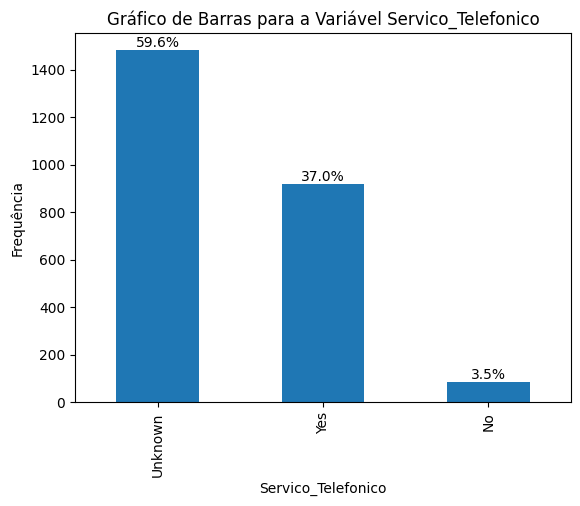

In [28]:
contagem = df['Servico_Telefonico'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Servico_Telefonico')
plt.xlabel('Servico_Telefonico')
plt.ylabel('Frequência')

plt.show()

Nota-se que a maior parte de clientes possuem o serviço telefonico 'Unknown'.

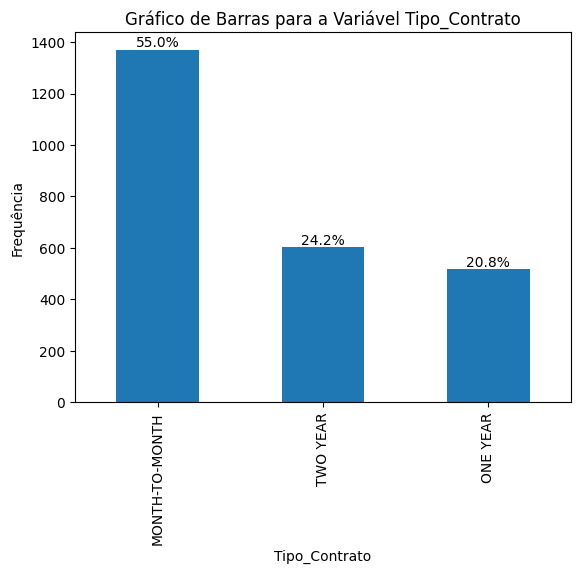

In [32]:
contagem = df['Tipo_Contrato'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Tipo_Contrato')
plt.xlabel('Tipo_Contrato')
plt.ylabel('Frequência')

plt.show()

Percebe-se que a o tipo de contrato predominante é o de 'MONTH_TO_MONTH'.

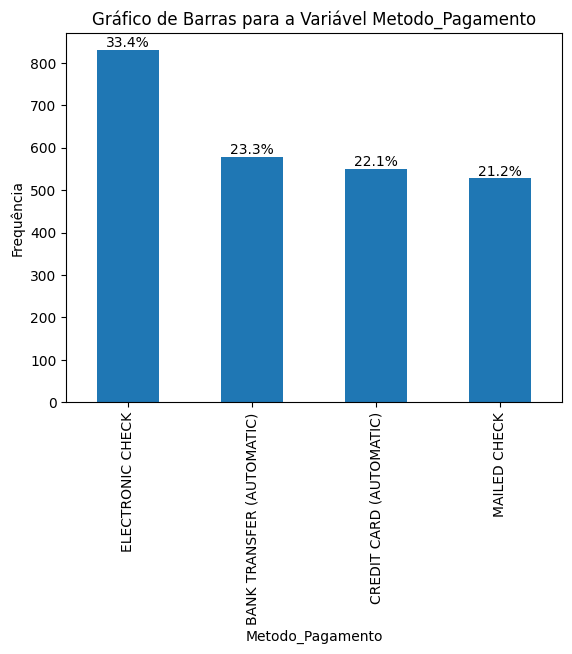

In [33]:
contagem = df['Metodo_Pagamento'].value_counts()
ax = contagem.plot(kind='bar')

# Total para calcular porcentagem
total = contagem.sum()

# Adicionando porcentagem nas barras
for i, valor in enumerate(contagem):
    porcentagem = valor / total * 100
    ax.text(i, valor, f'{porcentagem:.1f}%', ha='center', va='bottom')

plt.title('Gráfico de Barras para a Variável Metodo_Pagamento')
plt.xlabel('Metodo_Pagamento')
plt.ylabel('Frequência')

plt.show()

Por fim, o método de pagamento mais usado pelos clientes é o de 'ELETRONIC CHECK'.

Os principais insights da análise univariada são:
- A maioria de nossos clientes não são idosos, não possuem dependentes, serviço de segurança, suporte técnico e tv por streaming.
- Temos um balanceamento na categoria Casado, e Gênero.
- O serviço de internet predominante é o de Fibra Ótica.
- A maioria de clientes optam por pagar mês a mês, e com check eletrônico.

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


## No Exercício 2, já identifiquei os Outliers e também expliquei o motivo de mante-los.

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

Perguntas:
- Homens estão mais propensos a churn do que as mulheres?
- Algum serviço de internet tem maior proporção de churn?
- As variáveis total pago e tempo como cliente tem ligação e estão balanceadas? (Ex: quanto maior o tempo como cliente maior será o total pago)
- Quanto menor o tempo como cliente, maiores as chances de churn?
- Quanto mais caro os planos mensais, maiores as chances de churn?

In [8]:
df.head(10)

,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,TV_Por_Streaming,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,FEMALE,0,Yes,No,1,No,DSL,No,No,No,MONTH-TO-MONTH,ELECTRONIC CHECK,29.85,29.85,No
1,MALE,0,No,No,34,Yes,DSL,Yes,No,No,ONE YEAR,MAILED CHECK,56.95,1889.50,No
2,MALE,0,No,No,2,Yes,DSL,Yes,No,No,MONTH-TO-MONTH,MAILED CHECK,53.85,108.15,Yes
3,MALE,0,No,No,45,No,DSL,Yes,Yes,No,ONE YEAR,BANK TRANSFER (AUTOMATIC),71.45,1840.75,No
4,FEMALE,0,No,No,52,Yes,NO,No,No,No,ONE YEAR,MAILED CHECK,71.45,1022.95,No
5,MALE,0,No,Yes,71,Yes,FIBER OPTIC,Yes,No,Yes,TWO YEAR,BANK TRANSFER (AUTOMATIC),71.45,7382.25,No
6,FEMALE,0,Yes,Yes,10,Yes,DSL,No,Yes,No,MONTH-TO-MONTH,CREDIT CARD (AUTOMATIC),71.45,528.35,Yes
7,FEMALE,0,No,No,21,Yes,FIBER OPTIC,No,No,No,MONTH-TO-MONTH,ELECTRONIC CHECK,71.45,1862.90,No
8,MALE,1,No,No,1,No,DSL,No,No,No,MONTH-TO-MONTH,ELECTRONIC CHECK,71.45,39.65,Yes
9,MALE,0,Yes,No,12,Yes,NO,No,No,No,ONE YEAR,BANK TRANSFER (AUTOMATIC),71.45,202.25,No


In [7]:
df_grouped = df.groupby(['Churn', 'Genero']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Churn')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

fig = px.bar(df_grouped, x='Churn', y='percent', color='Genero', barmode='stack',
            labels={'Churn': 'Churn', 'percent': 'Porcentagem', 'Genero': 'Gênero'})

fig.update_layout(title='Relação entre Churn e Gênero',
                yaxis_title='Porcentagem',
                legend_title='Gênero')
fig.show()

In [16]:
df_grouped = df.groupby(['Churn', 'Servico_Internet']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Churn')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Churn', y='percent', color='Servico_Internet', barmode='stack',
            labels={'Churn': 'Churn', 'percent': 'Porcentagem', 'Servico_Internet': 'Servico_Internet'})

fig.update_layout(title='Relação entre Churn e Serviço de Internet',
                yaxis_title='Porcentagem',
                legend_title='Servico_Internet')
fig.show()

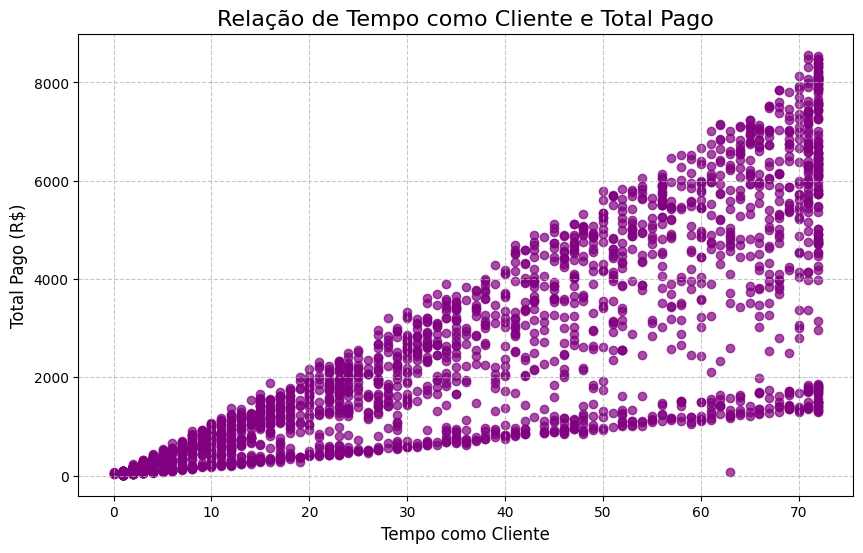

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Tempo_como_Cliente'], df['Total_Pago'], color='purple', alpha=0.7)

plt.title('Relação de Tempo como Cliente e Total Pago', fontsize=16)
plt.xlabel('Tempo como Cliente', fontsize=12)
plt.ylabel('Total Pago (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [7]:
mediana = df.groupby('Churn')['Tempo_como_Cliente'].median().reset_index()

fig = px.bar(mediana, x='Churn', y='Tempo_como_Cliente',
            title='Média Tempo como Cliente Churn')
fig.show()

In [10]:
fig = px.histogram(df, x='Churn', color='Idoso', barmode='stack')
fig.update_layout(title='Relação entre Churn e Idosos',
                xaxis_title='Churn',
                yaxis_title='Contagem',
                legend_title='Idoso')
fig.show()

In [13]:
mediana = df.groupby('Churn')['Pagamento_Mensal'].median().reset_index()

fig = px.bar(mediana, x='Churn', y='Pagamento_Mensal',
            title='Média Pagamento Mensal Churn')
fig.show()

Insights retirados:
- Nenhum gênero em específico tende a dar churn, temos um balanceamento nesse sentido.
- O serviço de internet Fibra Ótica tende a ter maior número de churn.
- Temos um equilíbrio e influência direta nas variables tempo como cliente e total pago.
- Quanto maior o tempo como cliente, menores as chances do cliente dar churn.
- Quanto mais caro for o plano mensal, maiores as chances do cliente dar churn.